# Fase 5 — Deriva Temporal da Pauta
**Projeto:** Deriva de Pauta nas Notícias do CNJ

Como a pauta se distribui e se **desloca** ao longo dos 6 meses, e que picos
emergem — cruzando-os com eventos verificáveis.

Apresenta os artefatos de `src/drift.py`. Reexecute com:
```bash
python src/drift.py --freq W --z 1.5
```

> **Atribuições usadas:** as **brutas** do HDBSCAN (alta confiança, sem
> outliers reatribuídos) — isso torna os picos e suas manchetes de evidência
> fiéis ao tema. As versões com `reduce_outliers` existem para cobertura total.
>
> **Honestidade sobre eventos:** os eventos de `reports/eventos_cnj.csv` são
> ancorados em **evidência do próprio corpus** (manchetes com URL verificável) e
> em **observâncias de calendário consolidadas** (ex.: 8/3, 18/5, 5/6). Não se
> citam números de resolução ou datas não auditáveis.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from drift import load_doc_topics, topic_time_matrix, detect_peaks, \
    peak_evidence, TOPIC_LABELS

PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "font.size": 10})

df = load_doc_topics()                       # brutas, sem outliers
mat = topic_time_matrix(df, freq="W")
eventos = pd.read_csv(ROOT / "reports" / "eventos_cnj.csv",
                      parse_dates=["data"])
print("Documentos classificados:", len(df), "| semanas:", mat.shape[0])
print("Eventos catalogados:", len(eventos))
eventos[["data", "evento", "tipo", "topico"]]

Documentos classificados: 691 | semanas: 26
Eventos catalogados: 11


,data,evento,tipo,topico
0,2026-03-08,Dia Internacional da Mulher / Mês da Mulher,observancia_calendario,4
1,2026-05-18,Dia Nacional de Combate ao Abuso e à Exploraçã...,observancia_calendario,6
2,2026-06-05,Dia Mundial do Meio Ambiente / Semana da Pauta...,observancia_calendario,7
3,2026-04-06,Estratégia Cuidar (saúde nas políticas penais)...,programa_cnj,2
4,2026-04-20,PopRuaJud — atendimento à população em situaçã...,programa_cnj,0
5,2026-05-18,Pena Justa — itinerância (Marajó),programa_cnj,5
6,2026-05-11,3º Prêmio de Inovação do Judiciário,evento_institucional,1
7,2026-03-02,Decisões disciplinares de alto perfil (afastam...,decisao_administrativa,8
8,2026-03-16,Nota de repúdio a ataques racistas (CNJ e STF),evento_institucional,3
9,2026-05-04,Atuação internacional (evento em Haia) e Nota ...,evento_institucional,3


## 1. Streamgraph da pauta (participação semanal por tópico)

Cada faixa é um tópico; a espessura é o nº de notícias na semana. Linhas
verticais marcam eventos de `eventos_cnj.csv`.

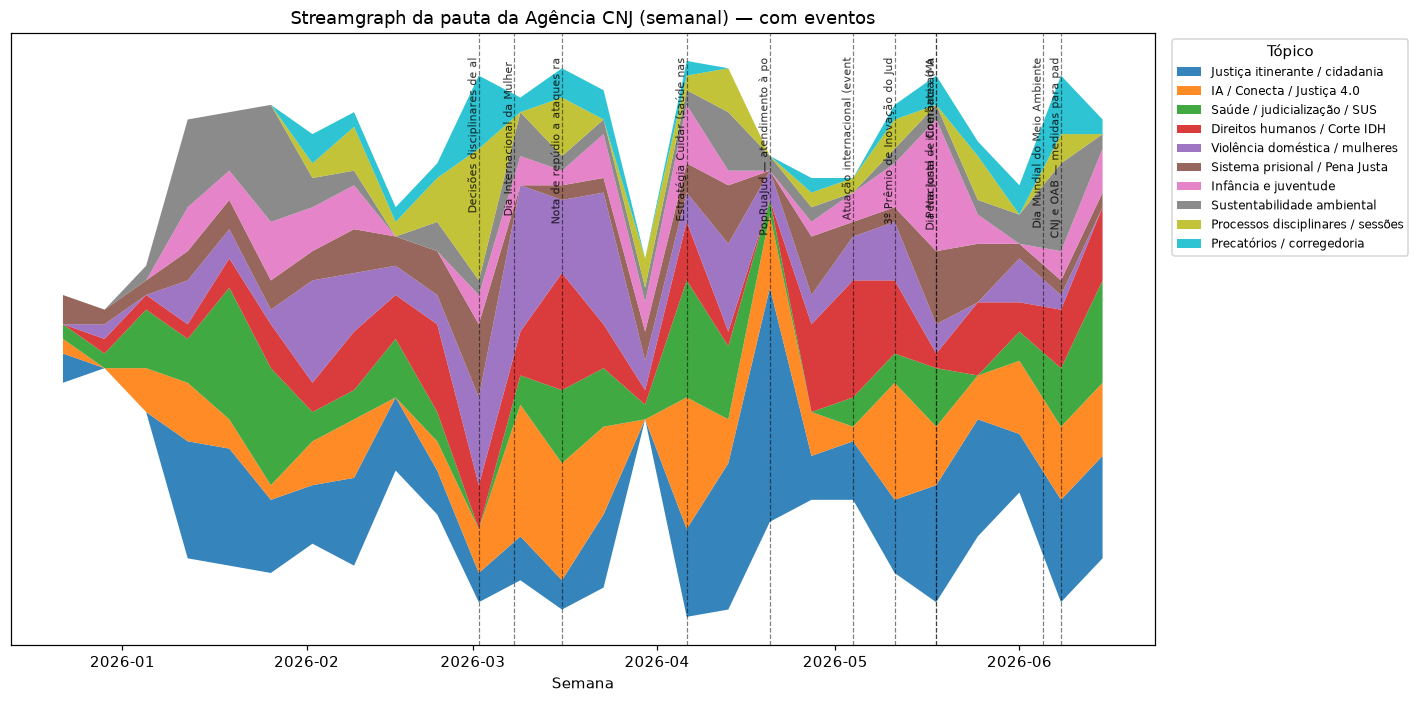

In [2]:
import matplotlib.cm as cm
topics = list(mat.columns)
colors = cm.tab10(np.linspace(0, 1, len(topics)))
labels = [TOPIC_LABELS.get(t, str(t)) for t in topics]

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.stackplot(mat.index, mat[topics].T.values, labels=labels,
             colors=colors, baseline="sym", alpha=0.9)

ymin, ymax = ax.get_ylim()
for _, e in eventos.iterrows():
    ax.axvline(e["data"], color="k", lw=0.8, ls="--", alpha=0.5)
    ax.text(e["data"], ymax * 0.92, str(e["evento"])[:28], rotation=90,
            va="top", ha="right", fontsize=7, alpha=0.8)
ax.set_title("Streamgraph da pauta da Agência CNJ (semanal) — com eventos")
ax.set_xlabel("Semana"); ax.set_yticks([])
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8,
          title="Tópico")
plt.tight_layout(); plt.savefig(FIG / "10_streamgraph.png",
                                bbox_inches="tight"); plt.show()

## 2. Picos por tópico e evidência

`scipy.signal.find_peaks` sobre a série semanal de cada tópico, com limiar
z ≥ 1,5 e contagem mínima. Para cada pico listamos manchetes reais da semana
(evidência verificável).

In [3]:
peaks = peak_evidence(df, detect_peaks(mat, z_thresh=1.5), freq="W", k=2)
show = peaks[["topic", "label", "periodo", "contagem", "z",
              "manchetes_evidencia"]].copy()
show["manchetes_evidencia"] = show["manchetes_evidencia"].str.slice(0, 90)
pd.set_option("display.max_colwidth", 95)
print(f"{len(peaks)} picos detectados")
show

20 picos detectados


,topic,label,periodo,contagem,z,manchetes_evidencia
0,0,Justiça itinerante / cidadania,2026-04-20,16,3.18,Acessibilidade: Justiça eleitoral do DF regulamenta atendimento externo para PcDs | Regist
1,1,IA / Conecta / Justiça 4.0,2026-03-09,9,2.02,e-MILIA: ferramenta traduz conteúdos jurídicos em linguagem simples no TJMSP | Seis formas
2,1,IA / Conecta / Justiça 4.0,2026-04-06,9,2.02,Webinário apresenta versão final do Sistema Nacional de Gestão de Bens | CNJ debate o futu
3,1,IA / Conecta / Justiça 4.0,2026-05-11,8,1.64,Abertas as inscrições para o 3º Prêmio de Inovação do Judiciário | Portal CNJ de Boas Prát
4,2,Saúde / judicialização / SUS,2026-01-19,9,2.31,Celeridade no 2º grau de jurisdição: TJAP fecha ano com 1.410 processos julgados | TRT-2 r
5,2,Saúde / judicialização / SUS,2026-04-06,8,1.91,"Saúde é o centro das políticas penais por meio da estratégia Cuidar, lançada pelo CNJ | 2ª"
6,3,Direitos humanos / Corte IDH,2026-03-16,8,2.19,Nota de repúdio do CNJ e do STF a ataques racistas | Evento no TJBA discute a gestão da po
7,3,Direitos humanos / Corte IDH,2026-05-04,8,2.19,Nota Oficial do Presidente do Conselho Nacional de Justiça | Políticas judiciárias brasile
8,4,Violência doméstica / mulheres,2026-02-02,7,1.50,CNJ avança na construção de diretrizes do programa para autores de violência doméstica | C
9,4,Violência doméstica / mulheres,2026-03-09,10,2.64,Ministra do STJ faz visita institucional ao CNJ para diálogo sobre enfrentamento à violênc


## 3. Tópicos selecionados ao longo do tempo (com picos)

Detalhe das séries dos tópicos com picos mais expressivos, marcando o evento
correlato.

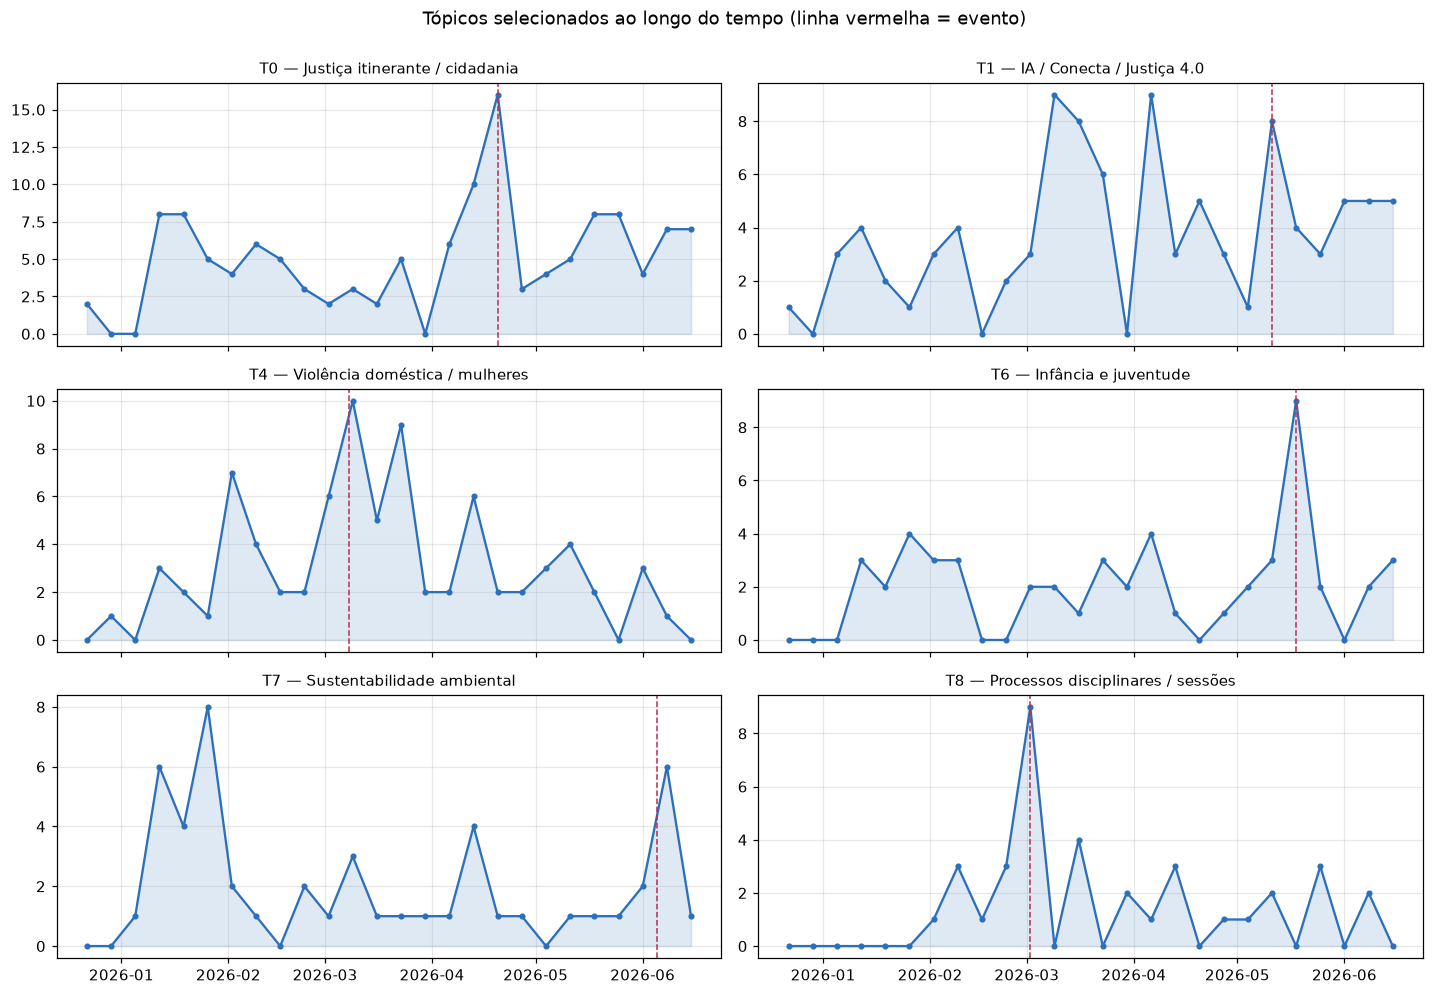

In [4]:
sel = [0, 1, 4, 6, 7, 8]   # itinerância, IA, mulheres, infância, ambiental, discipl.
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
for ax, t in zip(axes.flatten(), sel):
    s = mat[t]
    ax.plot(s.index, s.values, color="#2c6fbb", marker="o", ms=3)
    ax.fill_between(s.index, s.values, alpha=0.15, color="#2c6fbb")
    ax.set_title(f"T{t} — {TOPIC_LABELS[t]}", fontsize=10)
    for _, e in eventos[eventos["topico"] == t].iterrows():
        ax.axvline(e["data"], color="#bb2c4f", ls="--", lw=1)
    ax.grid(alpha=0.3)
fig.suptitle("Tópicos selecionados ao longo do tempo (linha vermelha = evento)",
             y=1.0)
plt.tight_layout(); plt.savefig(FIG / "11_topicos_no_tempo.png"); plt.show()

## 4. Quantificação da deriva (1º vs 2º semestre da janela)

Comparamos a participação de cada tópico na 1ª metade (22/12–20/03) e na 2ª
metade (21/03–19/06) do período. Δ em pontos percentuais (pp).

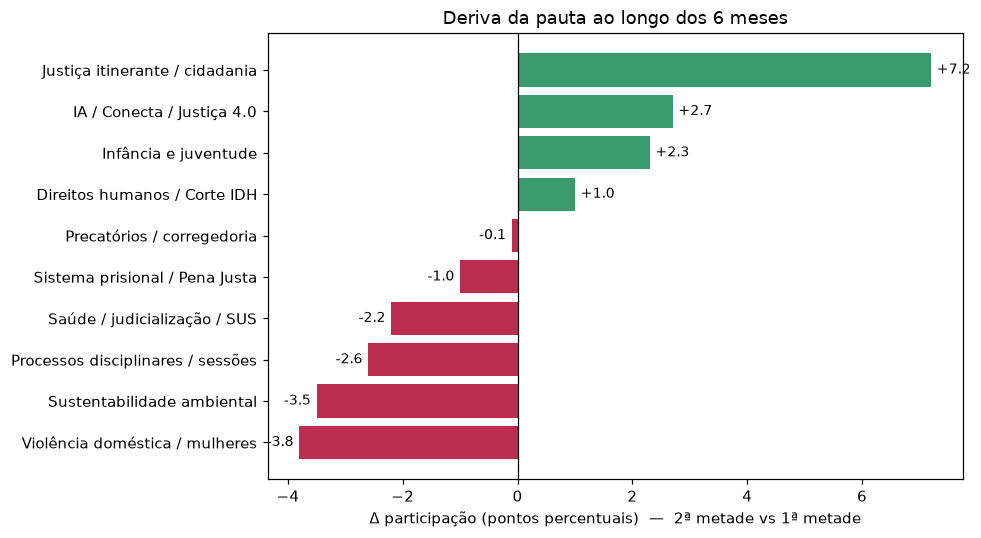

H1 (até 20/03): 318 docs | H2 (a partir de 21/03): 373 docs


,label,H1_%,H2_%,delta_pp
4,Violência doméstica / mulheres,13.5,9.7,-3.8
7,Sustentabilidade ambiental,9.1,5.6,-3.5
8,Processos disciplinares / sessões,6.6,4.0,-2.6
2,Saúde / judicialização / SUS,13.2,11.0,-2.2
5,Sistema prisional / Pena Justa,8.2,7.2,-1.0
9,Precatórios / corregedoria,4.1,4.0,-0.1
3,Direitos humanos / Corte IDH,11.3,12.3,1.0
6,Infância e juventude,6.3,8.6,2.3
1,IA / Conecta / Justiça 4.0,12.6,15.3,2.7
0,Justiça itinerante / cidadania,15.1,22.3,7.2


In [5]:
mid = pd.Timestamp("2026-03-21")
h1 = df[df["data_publicacao"] < mid]; h2 = df[df["data_publicacao"] >= mid]
s1 = h1["topic"].value_counts(normalize=True)
s2 = h2["topic"].value_counts(normalize=True)
drift = pd.DataFrame({
    "label": [TOPIC_LABELS[t] for t in sorted(TOPIC_LABELS)],
    "H1_%": [round(100*s1.get(t, 0), 1) for t in sorted(TOPIC_LABELS)],
    "H2_%": [round(100*s2.get(t, 0), 1) for t in sorted(TOPIC_LABELS)],
})
drift["delta_pp"] = (drift["H2_%"] - drift["H1_%"]).round(1)
drift = drift.sort_values("delta_pp")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#bb2c4f" if d < 0 else "#3a9a6d" for d in drift["delta_pp"]]
ax.barh(drift["label"], drift["delta_pp"], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ participação (pontos percentuais)  —  2ª metade vs 1ª metade")
ax.set_title("Deriva da pauta ao longo dos 6 meses")
for i, v in enumerate(drift["delta_pp"]):
    ax.text(v + (0.1 if v >= 0 else -0.1), i, f"{v:+.1f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "12_drift_h1_h2.png"); plt.show()
print(f"H1 (até 20/03): {len(h1)} docs | H2 (a partir de 21/03): {len(h2)} docs")
drift

## Síntese da Fase 5

**Picos correlacionados a eventos verificáveis:**
- **Violência doméstica/mulheres (T4)** picos nas semanas de março → *Mês da
  Mulher / 8 de março*; evidência: reuniões com magistradas sobre enfrentamento.
- **Infância e juventude (T6)** pico em 18/05 → *Dia Nacional de Combate ao
  Abuso e Exploração Sexual de Crianças e Adolescentes / Mês da Infância*;
  evidência: "Mês da Infância", lançamento de app de adoção (z=3,7).
- **Sustentabilidade (T7)** pico em jan (selos de carbono, reciclagem) e em
  08/06 → *Semana da Pauta Verde / Dia Mundial do Meio Ambiente*.
- **Saúde (T2)** pico em abr → *Estratégia Cuidar* + *2ª Semana da Saúde*.
- **Disciplinares (T8)** pico em 02/03 → decisões de alto perfil (afastamento de
  desembargador; pena por assédio).

**Deriva estrutural (não sazonal):**
- **Em alta:** *Justiça itinerante/cidadania* (+7,2pp) e *IA/Justiça 4.0*
  (+2,7pp) — crescimento genuíno da agenda de acesso à justiça e inovação.
- **Em queda:** *violência doméstica* (−3,9pp) e *sustentabilidade* (−3,5pp),
  quedas explicadas por concentração sazonal (março e janeiro, respectivamente).

> Pauta **não óbvia** revelada: o forte e crescente bloco de *Justiça
> itinerante / PopRuaJud / cidadania* — invisível na taxonomia editorial
> original (tudo era "Agência CNJ de Notícias"). Todos os números vêm da
> execução real de `src/drift.py`.